# Real catchment: ANUGA <-> stormwater coupling from one `.inp`

A **real** urban catchment (terrain, kerbs and walls exported from DRAINS),
coupled to its stormwater network through a single SWMM `.inp` via
{func}`~anuga_drainage.couple_from_inp`. This is the notebook companion to
`run_from_inp.py`: the only model-specific code is the ANUGA terrain domain, the
upstream inflow, and the evolve loop — the sewer network and the coupling inlets
are built straight from `real_example.inp`.

Run it from the `examples/real_example/` directory (the terrain/kerb/wall data
are read with relative paths). One `backend` variable picks the 1D solver: it
runs on **either** SWMM (pyswmm) or pipedream, and everything downstream uses
the backend-agnostic accessors, so switching is a one-line change.

In [1]:
%matplotlib inline
import glob, tempfile, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

import anuga
from anuga import create_domain_from_regions, Inlet_operator, Region
import anuga.utilities.spatialInputUtil as su
from anuga_drainage import couple_from_inp
from anuga_drainage.inp import read_inp

## The sewer network

`real_example.inp` is the DRAINS-exported stormwater network. We read its
sections with the package's zero-dependency parser just to see what we are
coupling to; `couple_from_inp` parses the same file to build the backend.

In [2]:
inp = read_inp('real_example.inp')
print('junctions:', list(inp.junctions['name']))
print('outfalls :', list(inp.outfalls['name']))
print('conduits :', len(inp.conduits))

junctions: ['Inlet_1', 'Inlet_2', 'Inlet_3', 'Inlet_4']
outfalls : ['Outfall_1']
conduits : 4


## The 2D terrain domain

Built from the catchment data under `model/`: the bounding polygon
(`domain.csv`), the kerb lines (interior regions), the walls (breaklines /
riverwalls) and the gridded `terrain.csv` elevation. Water is injected at one
upstream point and drains out through the `outflow` Dirichlet boundary. (Same
setup as `run_from_inp.py`.)

In [10]:
riverWalls, _ = su.readListOfRiverWalls(glob.glob('model/wall/*.csv'))
bounding_polygon = anuga.read_polygon('model/domain.csv')
interior_regions = anuga.read_polygon_dir(
    {'model/kerb/kerb1.csv': 0.01, 'model/kerb/kerb2.csv': 0.01}, 'model/kerb')

domain = create_domain_from_regions(
    bounding_polygon,
    boundary_tags={'inflow': [12, 13], 'bottom': [0, 1, 2, 3, 4, 5],
                   'top': [7, 8, 9, 10, 11], 'outflow': [6]},
    maximum_triangle_area=0.1, breaklines=riverWalls.values(),
    interior_regions=interior_regions, use_cache=False, verbose=False)
domain.set_minimum_storable_height(0.0)
domain.riverwallData.create_riverwalls(riverWalls, verbose=False)
domain.set_name('real_example_nb')
domain.set_epsg(32756)
domain.set_omp_num_threads(4)

domain.set_quantity('friction', 0.025)
domain.set_quantity('stage', 0)
domain.set_quantity('elevation', filename='model/terrain.csv', use_cache=False,
                    verbose=False, alpha=0.99)

domain.set_boundary({'inflow': anuga.Reflective_boundary(domain),
                     'bottom': anuga.Reflective_boundary(domain),
                     'outflow': anuga.Dirichlet_boundary([0, 0, 0]),
                     'top': anuga.Reflective_boundary(domain)})

inflow = Inlet_operator(domain, Region(domain, radius=1.0,
                        center=(305694.91, 6188013.94)), Q=0.102)
print(f'{len(domain)} triangles')

Setting omp_num_threads to 4
26135 triangles


## The geometry of the problem

The catchment terrain, with the sewer nodes (from the `.inp`) and the upstream
inflow point drawn on top. Elevation is in metres (UTM coordinates).

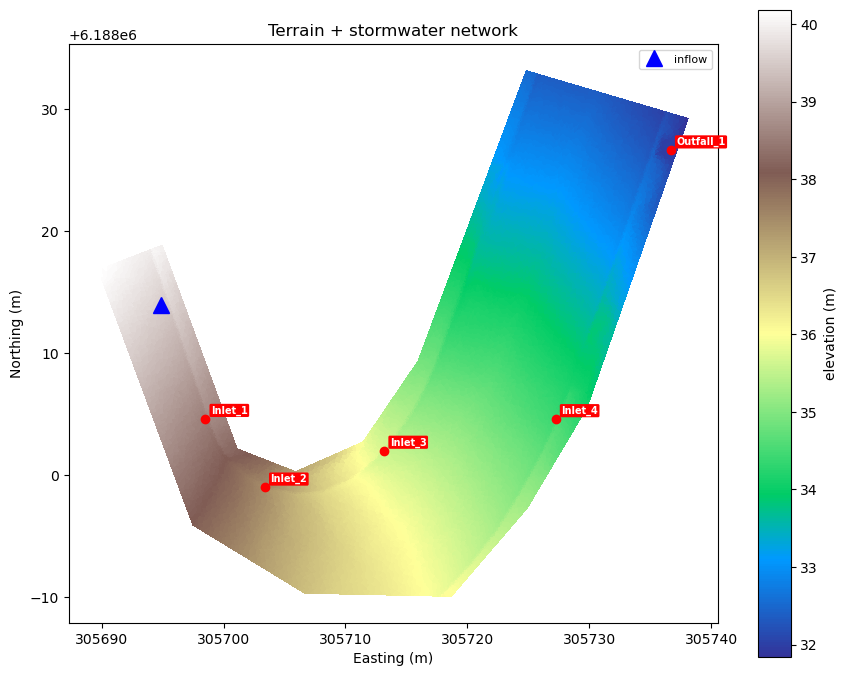

In [11]:
# domain.nodes are relative to the geo_reference origin; shift to absolute UTM
# so they line up with the .inp coordinates and the inflow point.
xll, yll = domain.geo_reference.xllcorner, domain.geo_reference.yllcorner
triang = mtri.Triangulation(domain.nodes[:, 0] + xll, domain.nodes[:, 1] + yll,
                            domain.triangles)
elev = domain.quantities['elevation'].centroid_values
coords = read_inp('real_example.inp').coordinates.set_index('node')

fig, ax = plt.subplots(figsize=(9, 7))
tpc = ax.tripcolor(triang, facecolors=elev, cmap='terrain')
fig.colorbar(tpc, ax=ax, label='elevation (m)')

ax.plot(305694.91, 6188013.94, 'b^', ms=11, label='inflow')
for name, row in coords.iterrows():
    ax.plot(row['x'], row['y'], 'o', color='red', ms=6)
    ax.annotate(name, (row['x'], row['y']), textcoords='offset points',
                xytext=(4, 4), fontsize=7, color='white', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', fc='red', ec='none'))
ax.set_aspect('equal'); ax.legend(loc='upper right', fontsize=8)
ax.set_title('Terrain + stormwater network')
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
fig.tight_layout()

## Run the coupling

Couple the domain to the network from the one `.inp`, attach a volume-balance
audit, and step the exchange every second while recording 2D depth frames for an
animation. (Outfalls drain *out* of the system here, so the outfall volume is a
sink, not returned to the surface.)

In [12]:
# Pick the 1D solver here — the rest of the notebook is backend-agnostic.
backend = 'swmm'          # 'swmm' (pyswmm) or 'pipedream'

coupling = couple_from_inp(domain, 'real_example.inp', backend=backend,
                           manhole_area=1.167, n_sides=6,
                           time_average=10.0, clamp=True,
                           pipedream_max_step=0.01)   # ignored by the swmm backend
coupling.add_volume_balance(inflow_operators=[inflow])
print(f'coupled {len(coupling.inlets)} junctions: {list(coupling.inlets)}  (backend={backend})')

# Generic 1D-network references — same accessors on both backends.
node_names = list(coupling.inlets)
conduit_names = coupling.backend.conduit_names()

plotter = anuga.Domain_plotter(domain, plot_dir=os.path.join(tempfile.mkdtemp(), 'frames'),
                               min_depth=0.01, absolute=True)  # UTM coords, matching the geometry plot
dt = 1.0
times, node_depth, conduit_flow = [], [], []
for i, t in enumerate(domain.evolve(yieldstep=dt, finaltime=100.0)):
    coupling.step(dt)
    times.append(t)
    node_depth.append(coupling.backend.node_depths())      # water depth in each manhole
    conduit_flow.append(coupling.backend.conduit_flows())  # flow through each conduit
    if i % 6 == 0:                                    # ~17 frames over 100 s
        plotter.save_depth_frame(vmin=0.0, vmax=0.15, figsize=(8, 6), dpi=80)
coupling.close()

times = np.array(times)
node_depth = np.array(node_depth)
conduit_flow = np.array(conduit_flow)

coupled 4 junctions: ['Inlet_1', 'Inlet_2', 'Inlet_3', 'Inlet_4']  (backend=swmm)
Figure files for each frame will be stored in /tmp/tmpfxaopasw/frames


## Watch the surface flow

2D water depth over the run (grey = dry terrain, colour = depth). Water spreads
from the inflow point and is drawn down into the pipe network at the inlets.

In [13]:
from matplotlib import rc
rc('animation', html='jshtml')

plotter.make_depth_animation()

## Water in the pipe network

The 1D side of the coupling over the run: the water **depth in each manhole**
(left) as the inlets capture surface water and fill the network, and the **flow
in each conduit** (right) carrying it down to the outfall.

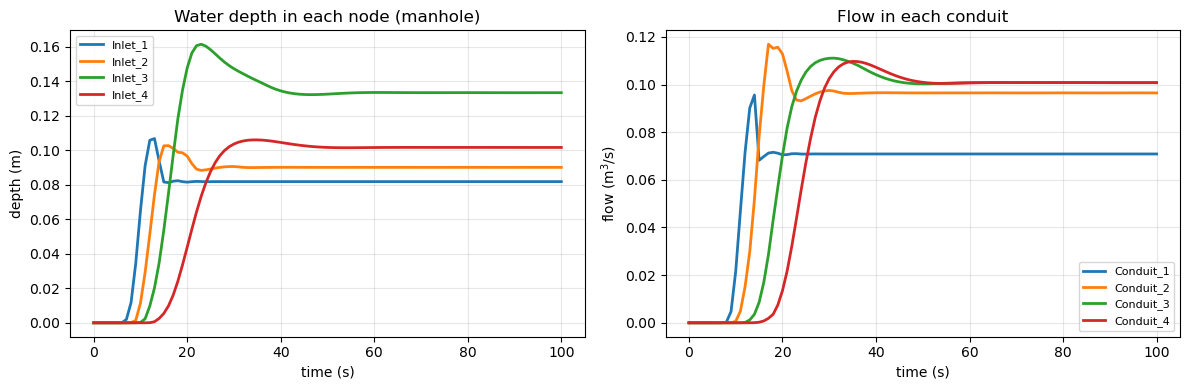

In [14]:
fig, (axd, axf) = plt.subplots(1, 2, figsize=(12, 4))
for j, name in enumerate(node_names):
    axd.plot(times, node_depth[:, j], lw=2, label=name)
axd.set_title('Water depth in each node (manhole)')
axd.set_xlabel('time (s)'); axd.set_ylabel('depth (m)')
axd.legend(fontsize=8); axd.grid(alpha=0.3)

for l, name in enumerate(conduit_names):
    axf.plot(times, conduit_flow[:, l], lw=2, label=name)
axf.set_title('Flow in each conduit')
axf.set_xlabel('time (s)'); axf.set_ylabel('flow (m$^3$/s)')
axf.legend(fontsize=8); axf.grid(alpha=0.3)
fig.tight_layout()

## Did it conserve?

The audit splits the balance into ANUGA, the pipe solver, and the coupling
handoff. `R_anuga` and `R_couple` are ~machine precision (ANUGA conserves; the
coupling conserves); the residual is `R_pipe` — SWMM's finite-difference loss.
The outfall term is water that has left the system at the network outfall.

In [15]:
print(coupling.volume_balance.summary().split('--- per inlet')[0])

Volume balance at t = 100 s
  ANUGA water    V_anuga =     1.266630  (start 0.000000)
  pipe water     V_pipe  =     1.498606  (start 0.000074)
  inflow source          =    10.200000
  boundary flux          =     0.000000
  inlets -> ANUGA        =    -8.933370
  inlets -> pipe         =     8.933370
  outfall <- pipe        =     7.759144
  --- residuals (should be ~0) ---
  R_anuga  (ANUGA closes)     = -1.003e-11
  R_pipe   (pipe closes)      =  3.243e-01
  R_couple (handoff consistent)= -7.105e-15
  total loss = R_anuga+R_pipe+R_couple =  3.243e-01
  


## Recap

One `.inp` drove the whole coupling on a real catchment: `couple_from_inp` built
the SWMM network and auto-placed an ANUGA inlet at each junction, and the evolve
loop exchanged water between the surface and the pipes every step — with the
volume audit confirming conservation. Set `backend = 'pipedream'` to run the same
model on the pipedream solver \u2014 the node/conduit references and plots are
backend-agnostic, so nothing else changes.